# Solving the Head and Neck Tumor Segmentation for MR-Guided Applications(HNTS-MRG) with UNETR

### Installing and setting up correct dependencies for the environment

In [4]:
!pip install -q "monai-weekly[nibabel, tqdm, einops]"
!python -c "import matplotlib" || pip install -q matplotlib
%matplotlib inline

In [5]:
import os
import shutil
import tempfile
from glob import glob
from sklearn.model_selection import train_test_split
import numpy as np

import matplotlib.pyplot as plt
import nibabel as nib
from tqdm import tqdm

from monai.losses import DiceCELoss
from monai.inferers import sliding_window_inference
from monai.transforms import (
    AsDiscrete,
    EnsureChannelFirstd,
    Compose,
    CropForegroundd,
    LoadImaged,
    Orientationd,
    RandFlipd,
    RandCropByPosNegLabeld,
    RandShiftIntensityd,
    ScaleIntensityRanged,
    Spacingd,
    RandRotate90d,
)

from monai.config import print_config
from monai.metrics import DiceMetric
from monai.networks.nets import UNETR

from monai.data import (
    DataLoader,
    Dataset,
    CacheDataset,
    load_decathlon_datalist,
    decollate_batch,
)


import torch

print_config()

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
2025-04-02 15:02:10.407357: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-02 15:02:10.432348: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-04-02 15:02:10.931285: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find Tensor

MONAI version: 1.5.dev2513
Numpy version: 1.26.4
Pytorch version: 2.4.1+cu121
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: ef083a32ccc13ee3937a4bd8acc12b9cdc174e18
MONAI __file__: /home/<username>/.local/lib/python3.10/site-packages/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: NOT INSTALLED or UNKNOWN VERSION.
ITK version: NOT INSTALLED or UNKNOWN VERSION.
Nibabel version: 5.3.2
scikit-image version: 0.21.0
scipy version: 1.8.0
Pillow version: 9.0.1
Tensorboard version: 2.16.2
gdown version: NOT INSTALLED or UNKNOWN VERSION.
TorchVision version: 0.19.1+cu121
tqdm version: 4.66.4
lmdb version: NOT INSTALLED or UNKNOWN VERSION.
psutil version: 5.9.5
pandas version: 1.3.5
einops version: 0.8.1
transformers version: NOT INSTALLED or UNKNOWN VERSION.
mlflow version: NOT INSTALLED or UNKNOWN VERSION.
pynrrd version: NOT INSTALLED or UNKNOWN VERSION.
clearml version: NOT INSTALLED or UNKNOWN VERSION.

For details about installing

### Setting up directories for training

Project is set up to access dataset stored at the Cybele lab at NTNU.

In [6]:
directory = "data_directory"
os.makedirs(directory, exist_ok=True)
root_dir = directory

# Define the correct training directory path
base_directory = "/datasets/tdt4265/mic/open/HNTS-MRG"

print(f"Base directory path: {base_directory}")
print(f"Base directory exists: {os.path.exists(base_directory)}")

Base directory path: /datasets/tdt4265/mic/open/HNTS-MRG
Base directory exists: True


### Hyperparameters

In [7]:
# Training parameters
max_iterations = 10
batch_size = 1

# Data processing parameters
train_validation_split = 0.8

# UNETR model parameters
patch_size=(64, 64, 32)
feature_size=16
hidden_size=768
mlp_dim=3072
num_heads=12
proj_type="perceptron"
norm_name="instance"
res_block=True
dropout_rate=0.0

# Optimizer parameters
lr=1e-4
weight_decay=1e-5

In [8]:
# Sort patients into a list in accending order
train_patients = sorted(glob(os.path.join(base_directory, "train", "[0-9]*")), key=lambda x: int(os.path.basename(x)))
test_patients = sorted(glob(os.path.join(base_directory, "test", "[0-9]*")), key=lambda x: int(os.path.basename(x)))

# Organize patients into dictionaries with image and corresponding label for each patient
train_files = []
for patient in train_patients:
    train_files.append({"image": glob(os.path.join(patient, "preRT", "[0-9]*_preRT_T2.nii.gz")), "label": glob(os.path.join(patient, "preRT", "[0-9]*_preRT_mask.nii.gz"))})
test_files = []
for patient in test_patients:
    test_files.append({"image": glob(os.path.join(patient, "preRT", "[0-9]*_preRT_T2.nii.gz")), "label": glob(os.path.join(patient, "preRT", "[0-9]*_preRT_mask.nii.gz"))})

# Split training into train and validation data
train_files, val_files = train_test_split(train_files, test_size=train_validation_split)

### Inspect images

Inspecting images to determine intensity values of the T2-weighted scans as these are not standardized in MR-scans.

In [46]:
samples = glob(os.path.join(base_directory, "train", "[0-9]*", "preRT", "[0-9]*_preRT_T2.nii.gz"))

min_intensities = []
max_intensities = []
mean_intensities = []
std_intensities = []
p1_intensities = []
p99_intensities = []

for sample in samples:
    img = nib.load(sample)
    data = img.get_fdata()

    min_intensities.append(data.min())
    max_intensities.append(data.max())
    mean_intensities.append(data.mean())
    std_intensities.append(data.std())
    p1_intensities.append(np.percentile(data, 1))
    p99_intensities.append(np.percentile(data, 99))

print(max(p99_intensities))
print(min(p1_intensities))

2571.5341796875
0.0


Using 1st and 99th percentiles to accurately capture intensities while also eliminating outliers from faulty scans.

### Transforms

Defining transformations for train and validation datasets

In [9]:
# Initial transforms for both training and validation datasets
pre_cache_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    Spacingd(keys=["image", "label"], pixdim=(1.5, 1.5, 2.0), mode=("bilinear", "nearest")),
    ScaleIntensityRanged(keys="image", a_min=0.0, a_max=2572.0, b_min=0.0, b_max=1.0, clip=True), #Using values found above
    CropForegroundd(keys=["image", "label"], source_key="image"),
])

# Random data augmentation for train dataset
post_cache_train_transforms = Compose([
    RandCropByPosNegLabeld(keys=["image", "label"], label_key="label", spatial_size=patch_size, pos=1, neg=1, num_samples=4, image_key="image", image_threshold=0),
    RandFlipd(keys=["image", "label"], spatial_axis=[0], prob=0.10),
    RandFlipd(keys=["image", "label"], spatial_axis=[1], prob=0.10),
    RandFlipd(keys=["image", "label"], spatial_axis=[2], prob=0.10),
    RandRotate90d(keys=["image", "label"], prob=0.10, max_k=3),
    RandShiftIntensityd(keys="image", offsets=0.10, prob=0.50)
])

/home/hermaos/.local/lib/python3.10/site-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.croppad.dictionary CropForegroundd.__init__:allow_smaller: Current default value of argument `allow_smaller=True` has been deprecated since version 1.2. It will be changed to `allow_smaller=False` in version 1.5.
  warn_deprecated(argname, msg, warning_category)


### Set up cache and dataloader

In [10]:
train_cache = CacheDataset(
    data=train_files,
    transform=pre_cache_transforms,
    cache_rate=1.0,
    num_workers=18, #24 threads available on Cybele computers
)

val_cache = CacheDataset(
    data=val_files,
    transform=pre_cache_transforms,
    cache_rate=1.0,
    num_workers=18, #Caching between train and val done in series, not at the same time
)

# Apply random transformations at access time
random_train_cache = Dataset(
    data=train_cache,
    transform=post_cache_train_transforms
)

train_loader = DataLoader(
    dataset=random_train_cache,
    batch_size=batch_size,
    shuffle=True,
    num_workers=18,
    pin_memory=True
)

val_loader = DataLoader(
    dataset=val_cache,
    batch_size=batch_size,
    shuffle=False,
    num_workers=18,
    pin_memory=True
)


Loading dataset: 100%|██████████| 104/104 [00:24<00:00,  4.26it/s]


### Checking transformations and dataloader by visualizing an image

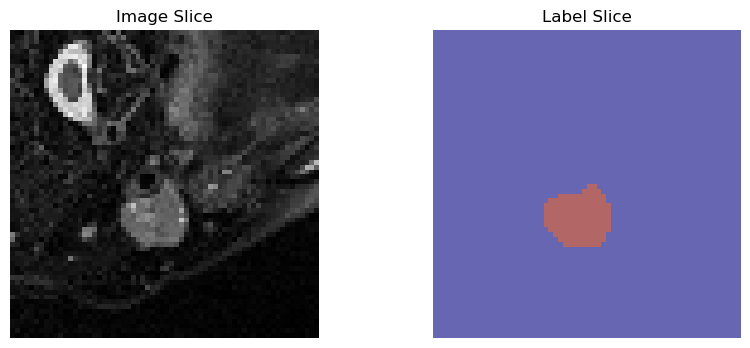

In [11]:
# Get a single scan after transformations
scan = next(iter(train_loader))

# Access image and label in scan
image = scan["image"]  # Shape: [B, C, H, W, D] for 3D images
label = scan["label"]  # Same shape as image, or [B, 1, H, W, D] if single-channel

# [B, C, H, W, D] → [H, W, D]
image_np = image[0][0].detach().cpu().numpy()
label_np = label[0][0].detach().cpu().numpy()

# Pick a central slice
slice_idx = image_np.shape[2] // 2
image_slice = image_np[:, :, slice_idx]
label_slice = label_np[:, :, slice_idx]

# Plot
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(image_slice, cmap="gray")
plt.title("Image Slice")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(label_slice, cmap="jet", alpha=0.6)
plt.title("Label Slice")
plt.axis("off")
plt.show()

### Defining model, optimizer and loss function

In [12]:
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNETR(
    in_channels=1,
    out_channels=3,
    img_size=patch_size,
    feature_size=feature_size,
    hidden_size=hidden_size,
    mlp_dim=mlp_dim,
    num_heads=num_heads,
    proj_type=proj_type,
    norm_name=norm_name,
    res_block=res_block,
    dropout_rate=dropout_rate,
).to(device)

loss_function = DiceCELoss(to_onehot_y=True, softmax=True)
torch.backends.cudnn.benchmark = True
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

### Setting up training and validation methods

In [ ]:
eval_num = 500
post_label = AsDiscrete(to_onehot=14)
post_pred = AsDiscrete(argmax=True, to_onehot=14)
dice_metric = DiceMetric(include_background=True, reduction="mean", get_not_nans=False)
global_step = 0
dice_val_best = 0.0
global_step_best = 0
epoch_loss_values = []
metric_values = []

def train(global_step, train_loader, dice_val_best, global_step_best):
    model.train()
    epoch_loss = 0
    epoch_iterator_train = tqdm(train_loader, dynamic_ncols=True)

    for step, batch in enumerate(epoch_iterator_train):
        image, label = (batch["image"].cuda(), batch["label"].cuda())
        pred = model(image)
        loss = loss_function(pred, label)
        loss.backward()
        epoch_loss += loss.item()
        optimizer.step()
        optimizer.zero_grad()

        if (global_step % eval_num == 0 and global_step != 0) or global_step == max_iterations:
            dice_val = validate(val_loader)
            metric_values.append(dice_val)
            
            if dice_val > dice_val_best:
                dice_val_best = dice_val
                global_step_best = global_step
                torch.save(model.state_dict(), os.path.join(root_dir, "best_metric_model.pth"))
                print(
                    "Model Was Saved ! Current Best Avg. Dice: {} Current Avg. Dice: {}".format(dice_val_best, dice_val)
                )
            else:
                print(
                    "Model Was Not Saved ! Current Best Avg. Dice: {} Current Avg. Dice: {}".format(
                        dice_val_best, dice_val
                    )
                )
        global_step += 1

    # Calculate and log average loss per epoch
    epoch_loss /= len(epoch_iterator_train)
    epoch_loss_values.append(epoch_loss)

    return global_step, dice_val_best, global_step_best

def validate(epoch_iterator_val):
    model.eval()
    with torch.no_grad():
        for step, batch in enumerate(epoch_iterator_val):
            image_val, label_val = (batch["image"].cuda(), batch["label"].cuda())
            outputs_val = sliding_window_inference(image_val, patch_size, 4, model)
            labels_val_list = decollate_batch(label_val)
            outputs_val_list = decollate_batch(outputs_val)
            labels_val_convert = [post_label(val_label_tensor) for val_label_tensor in labels_val_list]
            outputs_val_convert = [post_pred(val_pred_tensor) for val_pred_tensor in outputs_val_list]
            dice_metric(y_pred=outputs_val_convert, y=labels_val_convert)
        mean_dice_val = dice_metric.aggregate().item()
        dice_metric.reset()
    return mean_dice_val

while global_step < max_iterations:
    global_step, dice_val_best, global_step_best = train(global_step, train_loader, dice_val_best, global_step_best)
model.load_state_dict(torch.load(os.path.join(root_dir, "best_metric_model.pth"), weights_only=True))